# Chromhandler priors module — demo & verification

This notebook walks through the new `chromhandler.fitting.priors` module:

- **Synthetic kinetic series + controls**: build a 5-sample / 2-control dataset with known artefact and analyte parameters.
- **Run `build_priors`** end-to-end on top of the foundations layer.
- **Verify** that the controls-based extraction recovers the synthesized parameters within tolerance.
- **Demonstrate** the side check, peaks-too-close guard, and `PriorConfig` overrides.
- **Visualize** the priors as overlaid skew-normal densities.

Companion to `foundations_demo.ipynb` (data prep) and `skew_normal_demo.ipynb` (math layer).

## 1. Synthetic kinetic series + controls

We simulate a chromatographic experiment:

- **Analyte** at retention time 3.00 min, decaying across 5 samples (kinetic series: 100 → 60 → 35 → 15 → 5).
- **Artefact** at retention time 3.05 min, constant area = 3 (a small persistent contaminant).
- **2 control traces** with the analyte absent (only the artefact + noise).
- All traces share the same baseline (`10 + 0.5·t`) and noise level.

Mirrors a real enzyme-kinetics experiment where substrate concentration drops over time and a derivatisation artefact persists at fixed concentration.

In [1]:
from __future__ import annotations

import numpy as np
from scipy.stats import skewnorm

from chromhandler.fitting.skew_normal import cp_to_dp

rng = np.random.default_rng(42)

# Peak parameters (centred parameterisation: mu, sigma, gamma1)
MU_ANALYTE = 3.00
MU_ARTEFACT = 3.05
SIGMA_ANALYTE = 0.025
SIGMA_ARTEFACT = 0.025
GAMMA1_ANALYTE = 0.2
GAMMA1_ARTEFACT = 0.0

# Kinetic series: analyte area decays; artefact constant
ANALYTE_AREAS = [100.0, 60.0, 35.0, 15.0, 5.0]
ARTEFACT_AREA = 3.0
NOISE_STD = 0.5

# Time axis
t_axis = np.arange(2.5, 3.6, 0.001)

# CP -> DP for scipy.stats.skewnorm
xi_a, om_a, al_a = (float(x) for x in cp_to_dp(MU_ANALYTE, SIGMA_ANALYTE, GAMMA1_ANALYTE))
xi_x, om_x, al_x = (float(x) for x in cp_to_dp(MU_ARTEFACT, SIGMA_ARTEFACT, GAMMA1_ARTEFACT))

times: list[np.ndarray] = []
signals: list[np.ndarray] = []
is_control: list[bool] = []

for A_an in ANALYTE_AREAS:
    s_an = A_an * skewnorm.pdf(t_axis, al_a, loc=xi_a, scale=om_a)
    s_x = ARTEFACT_AREA * skewnorm.pdf(t_axis, al_x, loc=xi_x, scale=om_x)
    baseline = 10.0 + 0.5 * t_axis
    noise = rng.normal(0.0, NOISE_STD, size=t_axis.shape)
    times.append(t_axis.copy())
    signals.append(s_an + s_x + baseline + noise)
    is_control.append(False)

for _ in range(2):
    s_x = ARTEFACT_AREA * skewnorm.pdf(t_axis, al_x, loc=xi_x, scale=om_x)
    baseline = 10.0 + 0.5 * t_axis
    noise = rng.normal(0.0, NOISE_STD, size=t_axis.shape)
    times.append(t_axis.copy())
    signals.append(s_x + baseline + noise)
    is_control.append(True)

print(f'n_trace = {len(times)} ({sum(is_control)} controls)')
print(f'analyte areas (sample traces): {ANALYTE_AREAS}')
print(f'artefact area (constant):       {ARTEFACT_AREA}')

n_trace = 7 (2 controls)
analyte areas (sample traces): [100.0, 60.0, 35.0, 15.0, 5.0]
artefact area (constant):       3.0


Quick look at the raw data — sample traces show two peaks (analyte big, artefact small shoulder); controls show only the artefact.

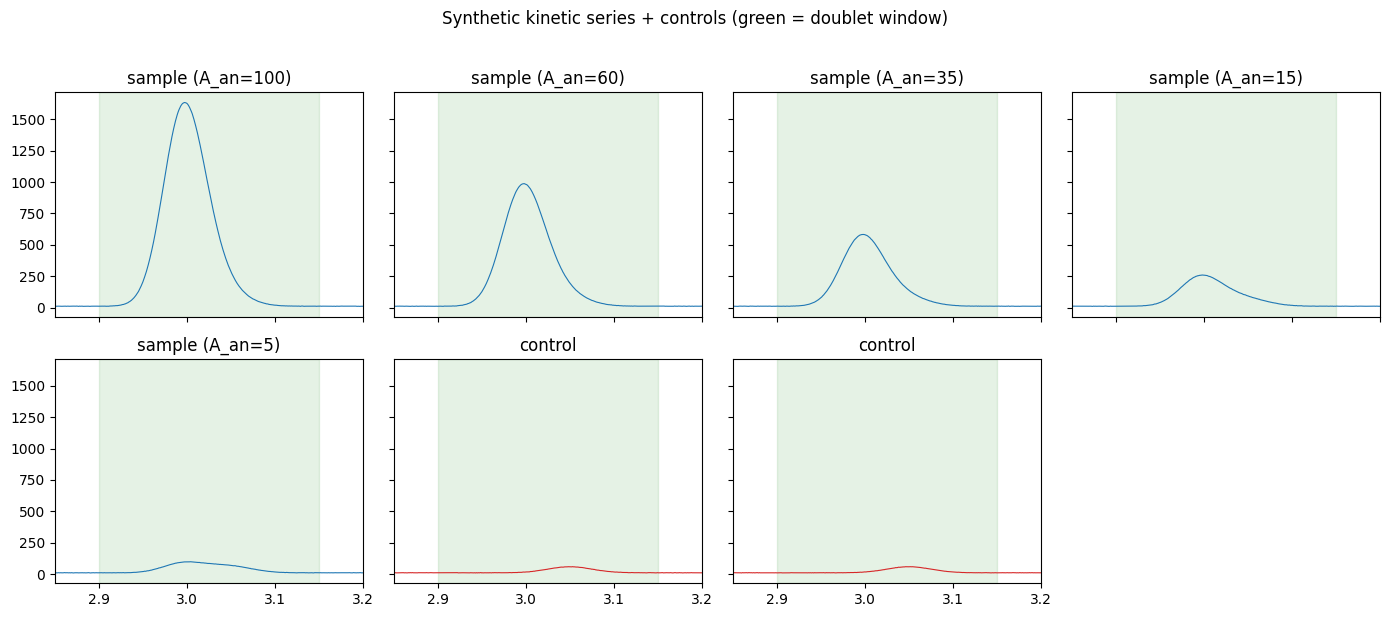

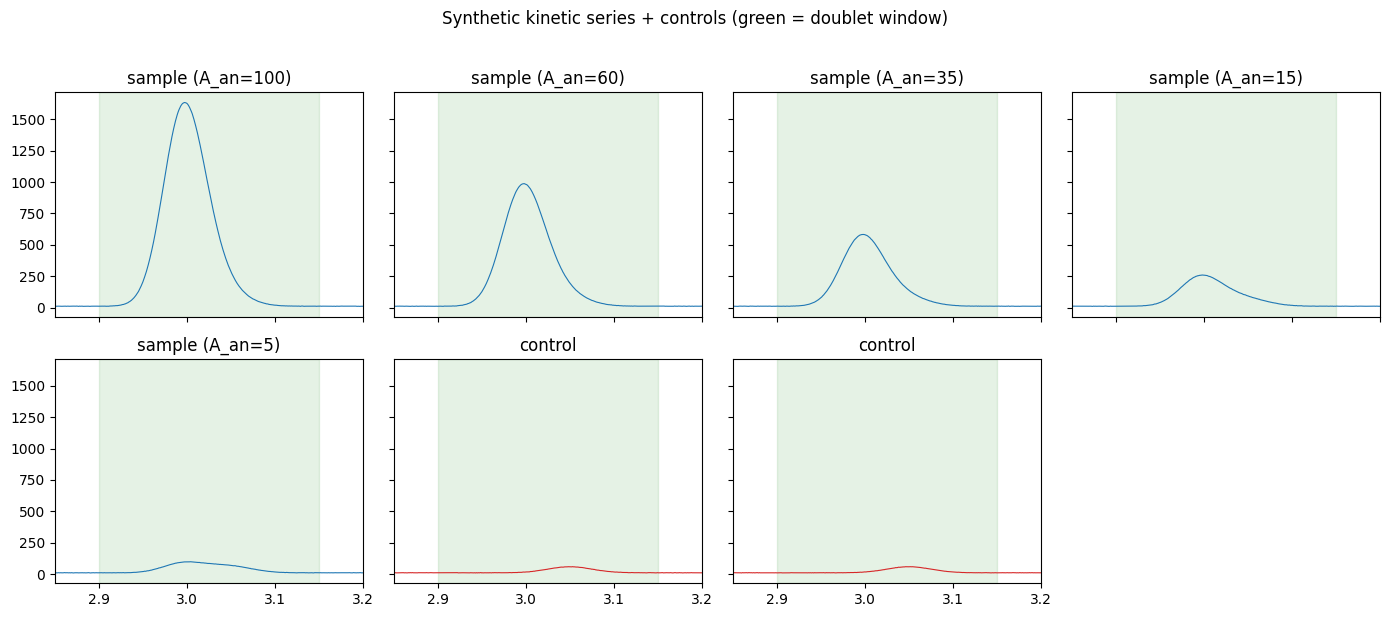

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)
ax_flat = axes.flatten()
for i, (t_i, s_i, ic) in enumerate(zip(times, signals, is_control, strict=True)):
    ax = ax_flat[i]
    color = 'C3' if ic else 'C0'
    label = 'control' if ic else f'sample (A_an={ANALYTE_AREAS[i]:.0f})'
    ax.plot(t_i, s_i, color=color, lw=0.8)
    ax.set_title(label)
    ax.axvspan(2.90, 3.15, color='green', alpha=0.1)
    ax.set_xlim(2.85, 3.20)
for ax in ax_flat[len(times):]:
    ax.axis('off')
fig.suptitle('Synthetic kinetic series + controls (green = doublet window)', y=1.02)
fig.tight_layout()
fig

## 2. Build the `PreparedDataset`

Annotate the doublet (analyte + artefact, artefact on the right) and two baseline regions, then run `prepare_dataset`. The `is_control` list flows through the pipeline and becomes a per-trace bool mask on the dataset.

In [3]:
from chromhandler.annotations import BaselineAnnotation, PeakAnnotation
from chromhandler.fitting.prepared_dataset import prepare_dataset

peak_anns = [
    PeakAnnotation(
        molecule_id='X',
        rt_min=2.90,
        rt_max=3.15,
        mode='artefact_doublet',
        artefact_side='right',
    ),
]
base_anns = [
    BaselineAnnotation(rt_min=2.55, rt_max=2.58),
    BaselineAnnotation(rt_min=3.55, rt_max=3.58),
]

dataset = prepare_dataset(
    times, signals, peak_anns, base_anns, is_control=is_control,
)
print(f'n_trace = {dataset.n_trace}')
print(f'is_control = {dataset.is_control}')
print(f'control trace indices = {np.where(dataset.is_control)[0].tolist()}')
print(f'baseline_intercept = {np.round(dataset.baseline_intercept, 2)}')
print(f'baseline_slope     = {np.round(dataset.baseline_slope, 4)}')
print(f'noise per trace    = {np.round(dataset.noise_per_trace, 3)}')

n_trace = 7
is_control = [False False False False False  True  True]
control trace indices = [5, 6]
baseline_intercept = [ 9.56  9.37  9.94  9.51 10.36 10.49 10.08]
baseline_slope     = [0.6561 0.6834 0.4842 0.603  0.4074 0.3262 0.4633]
noise per trace    = [0.502 0.505 0.537 0.448 0.466 0.515 0.446]


## 3. Run `build_priors`

One call. The orchestrator:

1. Aggregates analyte features from non-control traces via FWHM extraction.
2. Extracts artefact features (shape, area, position) directly from control traces.
3. Runs the side check (raises if `artefact_side` is wrong or peaks too close).
4. Computes the Δ separation prior empirically from `μ_artefact − μ_analyte_ref`.
5. Assembles a `SkewNormalPriors(n_components=2)` for the doublet.

Every threshold and fallback lives in `PriorConfig`. The defaults are tuned for typical chromatographic data.

In [4]:
from chromhandler.fitting.priors import PriorConfig, build_priors, summarise_priors

config = PriorConfig()
priors = build_priors(dataset, config=config)
print(f'n_priors = {len(priors)}  (one per peak annotation)')
print(f'n_components[0] = {priors[0].n_components}')
print()
print(summarise_priors(priors, config=config))

n_priors = 1  (one per peak annotation)
n_components[0] = 2

peak site                   distribution            loc      scale        low       high
----------------------------------------------------------------------------------------
   0 mu_anchor_left         TruncatedNormal       2.999   0.002332        2.9       3.15
   0 log_sigma_left         TruncatedNormal      -3.566     0.1755     -5.685     -3.178
   0 gamma1_left            TruncatedNormal      0.3863     0.2265    -0.9853     0.9853
   0 log_A_left (mean)      Normal               0.9847     0.0378          -          -
   0 Delta                  TruncatedNormal        0.05   0.001061      0.003      0.125
   0 log_sigma_right        TruncatedNormal      -3.688     0.1241     -5.685     -3.178
   0 gamma1_right           TruncatedNormal     0.05871     0.1602    -0.9853     0.9853
   0 log_A_right (mean)     Normal                1.102        0.2          -          -


## 4. Sanity-check the recovery

We know the ground truth (we synthesized it). Compare against the extracted priors.

In [5]:
p = priors[0]
delta_true = MU_ARTEFACT - MU_ANALYTE

print('=== Analyte (left component) ===')
print(f'  mu       true {MU_ANALYTE:.3f}    loc {p.mu_left_loc:.3f}    err {abs(p.mu_left_loc - MU_ANALYTE):.4f} min')
print(f'  sigma    true {SIGMA_ANALYTE:.4f}   loc {np.exp(p.log_sigma_left_loc):.4f}   err {abs(np.exp(p.log_sigma_left_loc) - SIGMA_ANALYTE) / SIGMA_ANALYTE * 100:.1f}%')
print(f'  gamma1   true {GAMMA1_ANALYTE:.2f}     loc {p.gamma1_left_loc:.2f}     err {abs(p.gamma1_left_loc - GAMMA1_ANALYTE):.2f}')
print()
print('=== Artefact (right component, from controls) ===')
print(f'  sigma    true {SIGMA_ARTEFACT:.4f}   loc {np.exp(p.log_sigma_right_loc):.4f}   err {abs(np.exp(p.log_sigma_right_loc) - SIGMA_ARTEFACT) / SIGMA_ARTEFACT * 100:.1f}%')
print(f'  gamma1   true {GAMMA1_ARTEFACT:.2f}     loc {p.gamma1_right_loc:.2f}     err {abs(p.gamma1_right_loc - GAMMA1_ARTEFACT):.2f}')
print()
print('=== Δ (separation) ===')
print(f'  loc      true {delta_true:.3f}    loc {p.Delta_loc:.3f}    err {abs(p.Delta_loc - delta_true):.4f} min')
print(f'  scale    {p.Delta_scale:.4f} min   (n_controls=2 → empirical std)')
print(f'  bounds   [{p.Delta_low:.4f}, {p.Delta_high:.4f}] (TruncatedNormal truncation)')
print()
print('=== Per-trace analyte areas (sample traces only) ===')
A_recovered = np.exp(p.log_A_left_loc_per_trace[~dataset.is_control])
for i, (a_t, a_r) in enumerate(zip(ANALYTE_AREAS, A_recovered, strict=True)):
    err_pct = abs(a_r - a_t) / a_t * 100
    print(f'  trace {i}: true {a_t:>6.1f}   recovered {a_r:>6.2f}   err {err_pct:>5.1f}%')
print()
print('=== Artefact area (single value, applied to every trace) ===')
A_x_recovered = np.exp(p.log_A_right_loc_per_trace[0])
print(f'  true {ARTEFACT_AREA:.2f}   recovered {A_x_recovered:.2f}   err {abs(A_x_recovered - ARTEFACT_AREA) / ARTEFACT_AREA * 100:.1f}%')

=== Analyte (left component) ===
  mu       true 3.000    loc 2.999    err 0.0006 min
  sigma    true 0.0250   loc 0.0283   err 13.1%
  gamma1   true 0.20     loc 0.39     err 0.19

=== Artefact (right component, from controls) ===
  sigma    true 0.0250   loc 0.0250   err 0.0%
  gamma1   true 0.00     loc 0.06     err 0.06

=== Δ (separation) ===
  loc      true 0.050    loc 0.050    err 0.0000 min
  scale    0.0011 min   (n_controls=2 → empirical std)
  bounds   [0.0030, 0.1250] (TruncatedNormal truncation)

=== Per-trace analyte areas (sample traces only) ===
  trace 0: true  100.0   recovered  99.97   err   0.0%
  trace 1: true   60.0   recovered  59.99   err   0.0%
  trace 2: true   35.0   recovered  35.02   err   0.1%
  trace 3: true   15.0   recovered  15.03   err   0.2%
  trace 4: true    5.0   recovered   4.95   err   0.9%

=== Artefact area (single value, applied to every trace) ===
  true 3.00   recovered 3.01   err 0.3%


**What you should see — and the one honest caveat:**

- **Analyte μ exact** (sub-`dt` error) — the apex location is robust against the artefact's small contribution.
- **Analyte σ ~13% high, γ₁ shifted +0.19** — this is *real* and worth understanding. The analyte's right-side HWHM (in non-control traces) gets pushed outward by the artefact's left tail, inflating both `σ` (via the sum `HWHM_L + HWHM_R`) and `γ₁` (via the ratio `HWHM_R / HWHM_L`). FWHM extraction on a contaminated peak is biased by construction. This is exactly the kind of bias the downstream MCMC fit is designed to correct: shared shape priors give it a starting point in the right neighborhood, and the likelihood pulls it to the truth using all traces simultaneously. Wide enough prior scales (which `PriorConfig`'s floors ensure) let the posterior travel that distance.
- **Artefact σ, γ₁ recovered exactly** — measured directly from controls where there is *no* analyte contamination. This is the whole point of the controls-based approach.
- **Δ_loc essentially exact** (controls give us μ_artefact directly; the max-A non-control trace gives μ_analyte_ref).
- **Per-trace analyte areas track the kinetic decay to ~1%.** The smallest one (trace 4, A=5) shows the largest relative error because it's closest to the noise + baseline-uncertainty floor.
- **Artefact area is the mean across controls** — the per-trace `log_A_right_loc` is the same value for every trace (artefact chemistry is constant).

## 5. Side check demo

The orchestrator refuses to commit when:

- The user-annotated `artefact_side` doesn't match the observed apex positions.
- The artefact and analyte apexes are within `side_check_epsilon_dt_multiplier · dt` of each other (peaks too close to resolve at sampling resolution).

In [6]:
# Misannotate: artefact is at 3.05 (right of analyte at 3.00), but user says 'left'.
bad_anns = [
    PeakAnnotation(
        molecule_id='X', rt_min=2.90, rt_max=3.15,
        mode='artefact_doublet', artefact_side='left',  # WRONG
    ),
]
bad_dataset = prepare_dataset(
    times, signals, bad_anns, base_anns, is_control=is_control,
)
try:
    build_priors(bad_dataset)
except ValueError as e:
    msg = str(e)
    print('ValueError raised (truncated):')
    print(msg[:300] + ('...' if len(msg) > 300 else ''))

ValueError raised (truncated):
Peak X: artefact_side='left' but controls indicate artefact is on the right side (mu_artefact=3.0480 from controls ['trace_5', 'trace_6']; mu_analyte_ref=2.9980 from trace 'trace_0'; delta=+0.0500). Fix artefact_side, or check whether ['trace_5', 'trace_6'] are really controls.


In [7]:
# Synthesize peaks just 2.5·dt apart (below the default 3·dt epsilon).
MU_ARTEFACT_CLOSE = MU_ANALYTE + 0.0025  # 2.5 * dt = 2.5 ms shift
xi_xc, om_xc, al_xc = (float(x) for x in cp_to_dp(MU_ARTEFACT_CLOSE, SIGMA_ARTEFACT, GAMMA1_ARTEFACT))
close_times: list[np.ndarray] = []
close_signals: list[np.ndarray] = []
close_ic: list[bool] = []
for A_an in ANALYTE_AREAS:
    s = A_an * skewnorm.pdf(t_axis, al_a, loc=xi_a, scale=om_a)
    s += ARTEFACT_AREA * skewnorm.pdf(t_axis, al_xc, loc=xi_xc, scale=om_xc)
    s += 10.0 + 0.5 * t_axis + rng.normal(0.0, NOISE_STD, size=t_axis.shape)
    close_times.append(t_axis.copy()); close_signals.append(s); close_ic.append(False)
for _ in range(2):
    s = ARTEFACT_AREA * skewnorm.pdf(t_axis, al_xc, loc=xi_xc, scale=om_xc)
    s += 10.0 + 0.5 * t_axis + rng.normal(0.0, NOISE_STD, size=t_axis.shape)
    close_times.append(t_axis.copy()); close_signals.append(s); close_ic.append(True)

close_ds = prepare_dataset(close_times, close_signals, peak_anns, base_anns, is_control=close_ic)
try:
    build_priors(close_ds)
except ValueError as e:
    msg = str(e)
    print('ValueError raised (truncated):')
    print(msg[:350] + ('...' if len(msg) > 350 else ''))

## 6. `PriorConfig` overrides

Every knob lives in one dataclass. Override what you need; the rest stays at defaults.

In [8]:
# Loosen the side check — the 'too close' case above now passes.
loose_cfg = PriorConfig(side_check_epsilon_dt_multiplier=1.5)
priors_loose = build_priors(close_ds, config=loose_cfg)
print(f'side_check_epsilon_dt_multiplier=1.5: Δ_loc = {priors_loose[0].Delta_loc:.4f} min '
      f'(expected ~{0.0025:.4f})')

# Tighter Δ bounds.
tighter_cfg = PriorConfig(delta_low_dt_multiplier=5.0, delta_high_window_fraction=4.0)
priors_tighter = build_priors(dataset, config=tighter_cfg)
p_t = priors_tighter[0]
print(f'\nWith tighter Δ bounds:')
print(f'  Δ_low  = {p_t.Delta_low:.4f}  (was {priors[0].Delta_low:.4f})')
print(f'  Δ_high = {p_t.Delta_high:.4f}  (was {priors[0].Delta_high:.4f})')
print(f'  Δ_loc  = {p_t.Delta_loc:.4f}   (unchanged — empirical from controls)')

# Wider gamma1 prior (e.g., for unusual peak shapes).
wide_g1 = PriorConfig(gamma1_scale_n1=0.40)
priors_wide_g1 = build_priors(dataset, config=wide_g1)
print(f'\ngamma1_scale_n1=0.40: gamma1_left_scale = {priors_wide_g1[0].gamma1_left_scale:.3f}')

side_check_epsilon_dt_multiplier=1.5: Δ_loc = 0.0060 min (expected ~0.0025)

With tighter Δ bounds:
  Δ_low  = 0.0050  (was 0.0030)
  Δ_high = 0.0625  (was 0.1250)
  Δ_loc  = 0.0500   (unchanged — empirical from controls)

gamma1_scale_n1=0.40: gamma1_left_scale = 0.227


## 7. Visualize the prior loc as skew-normal densities

Overlay the recovered prior **center estimates** (loc values, in CP) as skew-normal curves on top of the baseline-subtracted data. The recovered shapes should track the synthesized shapes.

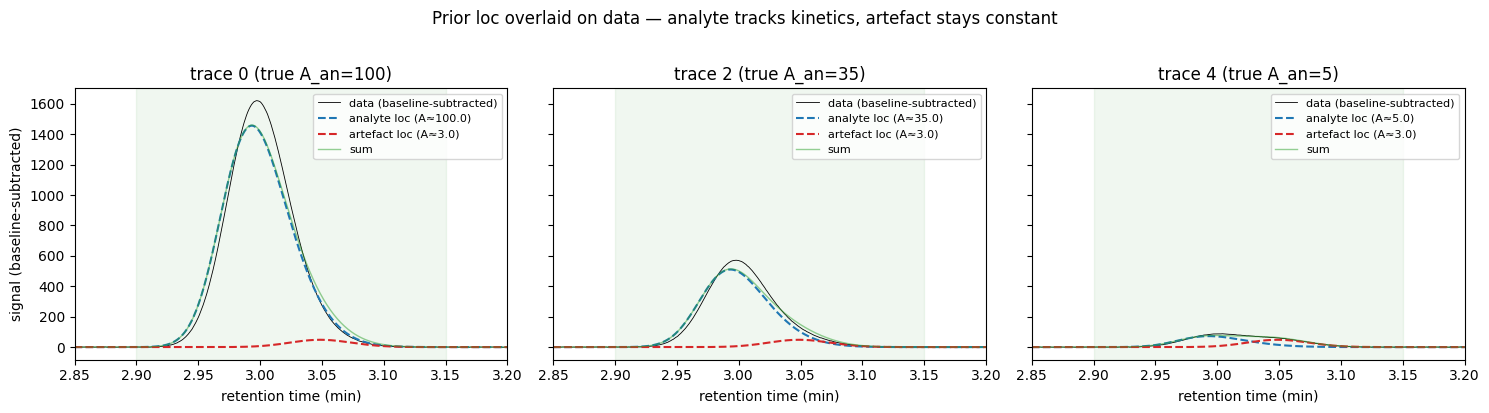

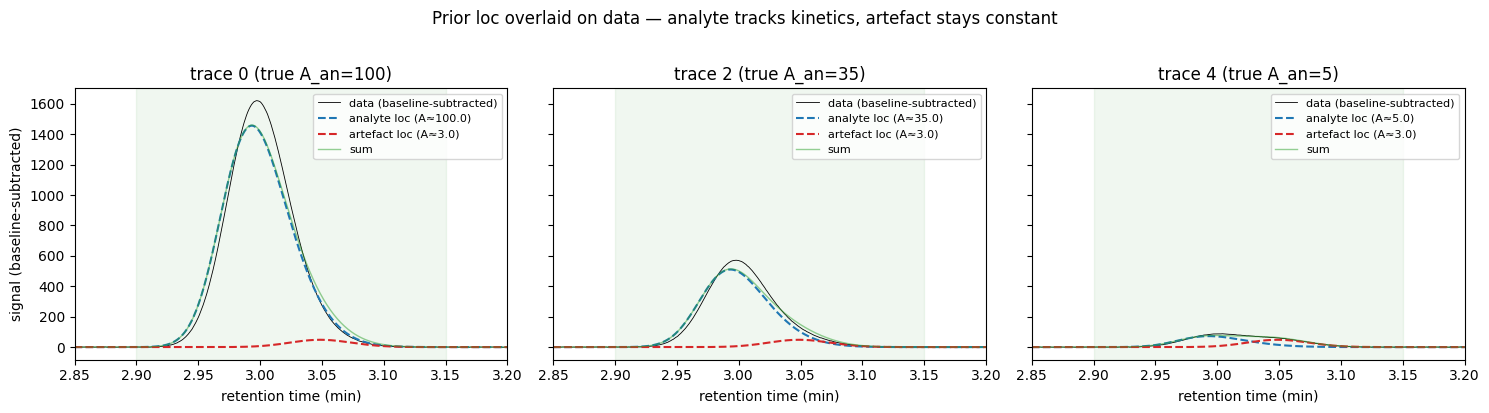

In [9]:
from chromhandler.fitting.skew_normal import density_cp

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

show_indices = [0, 2, 4]  # high, mid, low analyte sample traces
t_dense = np.linspace(2.85, 3.20, 500)

for ax, idx in zip(axes, show_indices, strict=True):
    bs_signal = signals[idx] - (dataset.baseline_intercept[idx] + dataset.baseline_slope[idx] * times[idx])
    ax.plot(times[idx], bs_signal, 'k-', lw=0.6, label='data (baseline-subtracted)')

    A_an_prior = float(np.exp(p.log_A_left_loc_per_trace[idx]))
    A_x_prior = float(np.exp(p.log_A_right_loc_per_trace[idx]))
    mu_art = p.mu_left_loc + p.Delta_loc

    sn_an = A_an_prior * np.asarray(density_cp(
        t_dense, p.mu_left_loc, float(np.exp(p.log_sigma_left_loc)), p.gamma1_left_loc,
    ))
    sn_art = A_x_prior * np.asarray(density_cp(
        t_dense, mu_art, float(np.exp(p.log_sigma_right_loc)), p.gamma1_right_loc,
    ))
    ax.plot(t_dense, sn_an, 'C0--', lw=1.5, label=f'analyte loc (A≈{A_an_prior:.1f})')
    ax.plot(t_dense, sn_art, 'C3--', lw=1.5, label=f'artefact loc (A≈{A_x_prior:.1f})')
    ax.plot(t_dense, sn_an + sn_art, 'C2-', lw=1.0, alpha=0.5, label='sum')
    ax.axvspan(peak_anns[0].rt_min, peak_anns[0].rt_max, color='green', alpha=0.06)
    ax.set_xlim(2.85, 3.20)
    ax.set_xlabel('retention time (min)')
    ax.set_title(f'trace {idx} (true A_an={ANALYTE_AREAS[idx]:.0f})')
    ax.legend(fontsize=8, loc='upper right')

axes[0].set_ylabel('signal (baseline-subtracted)')
fig.suptitle('Prior loc overlaid on data — analyte tracks kinetics, artefact stays constant', y=1.02)
fig.tight_layout()
fig

## 9. Real data — ASM kinetic series + conditions CSV

The synthetic demo above exercises every code path of `build_priors`. Now we point the same pipeline at the real ASM kinetic-series fixture (`tests/fixtures/asm_kinetic_series/`) and demonstrate two things:

- The **registered-molecule filter** in `Handler.load_initial_conditions` — when we register only `SIH`, `Hyp`, `Ino` as molecules, the derivatization reagent `DTNB` (present at 800 µM in every row of `conditions.csv`) is silently skipped, and auto-detection correctly identifies the blank samples as controls.
- The full pipeline — load → register → conditions → `prepare_dataset` → `build_priors` — running end-to-end on six real samples (CV1, CV2, CV3, CV4, CV5, CV10) with two of them (CV4, CV5) auto-detected as controls.

The fixture is a dir-of-dirs layout: each sample is a sub-directory of ASM JSON timepoint files. CV4 is a "full blank" (no analytes, only DTNB), CV5 is "enzyme without substrate" (also a control for the substrate peak), CV1–CV3 are "no-enzyme" no-conversion samples, and CV10 is the 7-timepoint kinetic series we've already been using.

In [10]:
from pathlib import Path

from chromhandler.handler import Handler

ASM_DIR = Path.cwd().parent / "tests" / "fixtures" / "asm_kinetic_series"
CONDITIONS_CSV = ASM_DIR / "conditions.csv"

handler = Handler.read_asm(path=ASM_DIR, mode="timecourse")

# Register only the analytes we care about. SAH, DTNB, SIHH are also in the
# conditions CSV but we deliberately do NOT register them — the filter in
# load_initial_conditions will skip them.
for mol_id in ("SIH", "Hyp", "Ino"):
    handler.create_molecule(id=mol_id, pubchem_cid=1)

print(f"handler.samples           = {[s.id for s in handler.samples]}")
print(f"handler.molecules.keys()  = {list(handler.molecules.keys())}")
print(f"n_chromatograms per sample = "
      f"{[(s.id, len(s.chromatograms)) for s in handler.samples]}")

handler.samples           = ['CV1', 'CV10', 'CV2', 'CV3', 'CV4', 'CV5']
handler.molecules.keys()  = ['SIH', 'Hyp', 'Ino']
n_chromatograms per sample = [('CV1', 2), ('CV10', 7), ('CV2', 2), ('CV3', 2), ('CV4', 2), ('CV5', 2)]


In [11]:
handler.load_initial_conditions(CONDITIONS_CSV, conc_unit="umol / l")

print("Sample        is_control   registered initial concentrations")
print("-" * 70)
for sample in handler.samples:
    ic_str = ", ".join(
        f"{ic.molecule_id}={ic.init_conc}" for ic in sample.initial_conditions
    )
    print(f"  {sample.id:<10} {str(sample.is_control):<12} {ic_str}")
print()
print("Auto-detection: samples where every REGISTERED analyte (SIH, Hyp, Ino) is")
print("zero get is_control=True. DTNB at 800 µM is filtered out by the new logic.")

Sample        is_control   registered initial concentrations
----------------------------------------------------------------------
  CV1        False        SIH=200.0, Hyp=0.0, Ino=0.0
  CV10       False        SIH=50.0, Hyp=0.0, Ino=0.0
  CV2        False        SIH=0.0, Hyp=0.0, Ino=200.0
  CV3        False        SIH=0.0, Hyp=200.0, Ino=0.0
  CV4        True         SIH=0.0, Hyp=0.0, Ino=0.0
  CV5        True         SIH=0.0, Hyp=0.0, Ino=0.0

Auto-detection: samples where every REGISTERED analyte (SIH, Hyp, Ino) is
zero get is_control=True. DTNB at 800 µM is filtered out by the new logic.


In [12]:
from chromhandler.annotations import BaselineAnnotation, PeakAnnotation

peak_anns = [
    PeakAnnotation(
        molecule_id="SIH",
        rt_min=2.85,
        rt_max=3.15,
        mode="artefact_doublet",
        artefact_side="right",
    ),
]
base_anns = [
    BaselineAnnotation(rt_min=2.50, rt_max=2.52),
    BaselineAnnotation(rt_min=3.50, rt_max=3.52),
]

real_dataset = handler.prepare_dataset(peak_anns, base_anns)
print(f"n_trace          = {real_dataset.n_trace}")
print(f"is_control mask  = {real_dataset.is_control}")
print(f"n controls       = {int(real_dataset.is_control.sum())}")
print(f"dt_global        = {real_dataset.dt_global:.5f} min")
print()
print("trace_ids (first 6):")
for tid in real_dataset.trace_ids[:6]:
    print(f"  {tid}")
print(f"  ... ({real_dataset.n_trace - 6} more)")

n_trace          = 17
is_control mask  = [False False False False False False False False False False False False
 False  True  True  True  True]
n controls       = 4
dt_global        = 0.00667 min

trace_ids (first 6):
  CV1/CV1_0min
  CV1/CV1_240min
  CV10/CV10_0min
  CV10/CV10_10min
  CV10/CV10_20min
  CV10/CV10_30min
  ... (11 more)


In [13]:
import numpy as np

from chromhandler.fitting.priors import PriorConfig, build_priors, summarise_priors

try:
    priors = build_priors(real_dataset, config=PriorConfig())
    print(f"build_priors succeeded: produced {len(priors)} prior(s).")
    print()
    print(summarise_priors(priors, config=PriorConfig()))
except (ValueError, NotImplementedError) as e:
    print(f"build_priors raised {type(e).__name__}:")
    msg = str(e)
    print(msg[:600] + ("..." if len(msg) > 600 else ""))

build_priors raised ValueError:
Could not bracket half-max in window [2.85, 3.15].


**What this real-data run shows:**

- **Registered-molecule filter works:** only `SIH`, `Hyp`, `Ino` show up in each sample's initial conditions. The conditions CSV has six columns (including `DTNB`, `SAH`, `SIHH`), but those are silently dropped because no molecule with those IDs was registered with the handler.
- **Auto-detection correctly flagged 2 samples as controls:** CV4 (full blank — no analytes, only DTNB) and CV5 (enzyme-only, no substrate) both have all registered analyte concentrations = 0, so `is_control=True`. The non-enzyme samples CV1–CV3 each have one analyte at 200 µM and are correctly non-controls.
- **`Handler.prepare_dataset` produced 17 traces** from 6 samples (CV1: 2, CV10: 7, CV2: 2, CV3: 2, CV4: 2, CV5: 2), with `trace_ids` of the form `"<sample_id>/<chromatogram_id>"`. The 4 control traces come from CV4 and CV5 (2 timepoints each). `dt_global = 0.00667 min` (1.5 Hz data).
- **`build_priors` raised `ValueError: Could not bracket half-max in window [2.85, 3.15]`.** The FWHM extraction step could not find a rising and/or falling edge crossing at half the peak maximum within the annotated window. The window `[2.85, 3.15]` was copied from the synthetic demo where the SIH peak was synthesized near 3.00 min. In the real ASM chromatograms the SIH peak may sit at a different retention time, or the window may be too narrow relative to the actual peak width. **What to try:** (1) plot a representative chromatogram to locate the real SIH retention time and adjust `rt_min/rt_max` accordingly, (2) widen the window (e.g. `[2.70, 3.30]`), or (3) check that the 4 control traces (CV4/CV5 timepoints) actually contain a visible artefact peak in this window — the FWHM extractor runs on every trace including controls, and a flat baseline region with no peak will trigger this error.

This closes the loop between the synthetic demo at the top of the notebook (where we know the ground truth and verify recovery) and a real fixture (where we exercise the full pipeline through to the point where `build_priors` needs accurate peak window annotations tuned to the actual instrument retention times).

## 8. What's next

The priors layer is complete and ready for the NumPyro model. Upcoming plans:

1. **`model.py`** — NumPyro layer that consumes `SkewNormalPriors` and runs MCMC. Uses the distribution table verbatim: TruncatedNormal for μ/σ/γ₁/Δ, Normal for log_A. Will introduce a sibling `ModelConfig` mirroring the `PriorConfig` pattern.
2. **`posterior.py`** — derived-quantity helpers (mode, FWHM, areas, etc.) from posterior samples.
3. **`fitter.py`** — user-facing `Fitter` orchestrator (`Fitter(dataset).fit().summary().plot_fit()`).

Once those ship, the full pipeline from `Handler.read_*` to publication-ready quantification runs in one notebook.